In [8]:
# Install numba and ipympl before the accelerated cells
%pip install -q ipympl numba


Note: you may need to restart the kernel to use updated packages.


In [9]:
# The engine — single source of truth
# numba kernel if available, vectorised numpy otherwise.
# The explorer, the box magnifier, and escape_time all call _engine.

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    from numba import njit, prange

    # Escape-time counts; +inf = did not escape (interior, or not yet).
    # Mandelbrot: main cardioid + period-2 disk filled in analytically.
    # Julia: tight escape radius R = (1 + sqrt(1 + 4|c|))/2.
    # Cycle detection: a near-return is only believed after one full lap
    # returns again AND the cycle multiplier |(f^p)'|^2 < 1.  Attracting
    # cycles are interior; orbits shadowing a repelling cycle are not.
    @njit(parallel=True, fastmath=True)
    def _engine(re, im, max_iter, cre, cim, julia):
        out = np.empty((im.size, re.size))
        if julia:
            cabs = np.hypot(cre, cim)
            R = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * cabs))
            bail = 16.0 if R < 4.0 else R * R
        else:
            bail = 16.0
        for j in prange(im.size):
            yi = im[j]
            y2 = yi * yi
            for i in range(re.size):
                xi = re[i]
                if julia:
                    zr, zi, cr, ci = xi, yi, cre, cim
                else:
                    zr, zi, cr, ci = 0.0, 0.0, xi, yi
                    xq = xi - 0.25
                    q = xq * xq + y2
                    # main cardioid, or the period-2 disk
                    if q * (q + xq) <= 0.25 * y2 or (xi + 1.0) * (xi + 1.0) + y2 <= 0.0625:
                        out[j, i] = np.inf
                        continue
                z2 = zr * zr + zi * zi
                if z2 > bail:                                  # already outside
                    out[j, i] = 1.0 - np.log2(np.log2(z2) * 0.5)
                    continue
                mu = np.inf
                zr0, zi0 = zr, zi    # reference point, refreshed every 20 steps
                vr = vi = 0.0        # candidate periodic point while verifying
                lag = 0              # steps since the reference
                left = 0             # verification countdown
                wm2 = 1.0            # |(f^p)'|^2, accumulated over the lap
                for k in range(1, max_iter + 1):
                    zr, zi = zr*zr - zi*zi + cr, 2.0*zr*zi + ci
                    z2 = zr*zr + zi*zi
                    if not z2 <= bail:                          # escaped (NaN-safe)
                        if np.isfinite(z2) and z2 > 1.0:
                            mu = k - np.log2(np.log2(z2) * 0.5) + 1.0
                        else:
                            mu = float(k)
                        break
                    if left > 0:                                # verification lap
                        wm2 *= 4.0 * z2                         # *= |2z|^2 this step
                        left -= 1
                        if left == 0:
                            dr, di = zr - vr, zi - vi
                            if dr*dr + di*di < 1e-20 and wm2 < 1.0:
                                break                           # attracting -> interior
                            zr0, zi0, lag = zr, zi, 0           # false alarm; resume
                    else:                                       # watching for a return
                        lag += 1
                        dr, di = zr - zr0, zi - zi0
                        if dr*dr + di*di < 1e-20:
                            vr, vi = zr, zi                     # candidate; verify it
                            left, wm2 = lag, 1.0
                        elif lag == 20:
                            zr0, zi0, lag = zr, zi, 0
                out[j, i] = mu
        return out
    _ACCEL = "numba"

except ImportError:
    # Vectorised fallback.  Deliberately no cycle detection: interior orbits
    # simply run to max_iter and return +inf, which colours black exactly like
    # the kernel's verified early exit — same image, only the speed differs.
    def _engine(re, im, max_iter, cre, cim, julia):
        grid = re[None, :] + 1j * im[:, None]
        if julia:
            z = grid
            c = np.full_like(grid, complex(cre, cim))
            cabs = np.hypot(cre, cim)
            R = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * cabs))
            bail = 16.0 if R < 4.0 else float(R * R)
            main = np.zeros(grid.shape, dtype=bool)
        else:
            z = np.zeros_like(grid)
            c = grid
            x, y = c.real, c.imag
            q = (x - 0.25)**2 + y**2
            main = (q * (q + (x - 0.25)) <= 0.25 * y**2) | ((x + 1.0)**2 + y**2 <= 0.0625)
            bail = 16.0
        mu = np.full(z.shape, np.inf)
        alive = ~main
        z2 = z.real**2 + z.imag**2
        pre = alive & (z2 > bail)          # already beyond the escape radius
        if pre.any():
            mu[pre] = 1.0 - np.log2(np.log2(z2[pre]) / 2.0)
            alive[pre] = False
        for k in range(1, max_iter + 1):
            if not alive.any():
                break
            za = z[alive] * z[alive] + c[alive]
            z[alive] = za
            a2 = za.real**2 + za.imag**2
            esc = ~np.isfinite(a2) | (a2 > bail)
            if esc.any():
                idx = np.flatnonzero(alive)[esc]
                a2e = a2[esc]
                ok = np.isfinite(a2e) & (a2e > 1.0)
                vals = np.full(idx.shape, float(k))
                if ok.any():
                    vals[ok] = k + 1.0 - np.log2(np.log2(a2e[ok]) / 2.0)
                mu.ravel()[idx] = vals
                alive.ravel()[idx] = False
        return mu
    _ACCEL = "numpy (pip install numba for ~20–40× speedup)"

def escape_time(center, span, pixels=800, max_iter=300, julia_c=None):
    """Thin wrapper so the static cells read nicely.
       julia_c=None -> Mandelbrot (z starts at 0, c roams the screen)
       julia_c=c    -> Julia      (z roams the screen, c is pinned)
       Returns smooth escape counts; +inf = stays bounded (renders black)."""
    re = np.linspace(center.real - span/2, center.real + span/2, pixels)
    im = np.linspace(center.imag - span/2, center.imag + span/2, pixels)
    jc = julia_c if julia_c is not None else 0j
    return _engine(re, im, max_iter, jc.real, jc.imag, julia_c is not None)

def color_limits(finite):
    """Color range from the central 99% of escaped pixels, so one speck
    does not stretch the scale."""
    if getattr(finite, "size", 0) == 0:
        return None
    lo, hi = np.percentile(np.asanyarray(finite, dtype=float), [0.5, 99.5])
    lo, hi = float(lo), float(hi)
    if not hi > lo:
        hi = lo + 1.0
    return lo, hi

def show(mu, center, span, cmap="magma", title=""):
    cm = mpl.colormaps[cmap].copy()
    cm.set_bad("black")
    data = np.ma.masked_invalid(mu)
    plt.figure(figsize=(8, 8))
    im = plt.imshow(data, cmap=cm,
                    extent=(center.real - span/2, center.real + span/2,
                            center.imag - span/2, center.imag + span/2),
                    origin="lower", interpolation="bilinear")
    lim = color_limits(data.compressed())
    if lim:
        im.set_clim(*lim)
    plt.title(title); plt.axis("off"); plt.show()


1985 mode, the Dewdney homage (ASCII, like the dot-matrix printouts readers mailed in — except his took all night, and this takes a second)

In [10]:
# Cell 2
# 1985 mode, Dewdney homage
def ascii_mandelbrot(cols=80, rows=30, max_iter=60):
    shades = " .:-=+*#%@"
    lines = []
    for r in range(rows):
        y = 1.15 - 2.3 * r / (rows - 1)
        row = ""
        for i in range(cols):
            x = -2.1 + 2.8 * i / (cols - 1)
            zr, zi, cr, ci = 0.0, 0.0, x, y
            k = 0
            while k < max_iter and zr*zr + zi*zi <= 4.0:
                zr, zi = zr*zr - zi*zi + cr, 2.0*zr*zi + ci
                k += 1
            row += shades[k * 9 // max_iter]
        lines.append(row)
    return "\n".join(lines)

print(ascii_mandelbrot())

                                                                                
                                                      ..                        
                                                     .....:.                    
                                                    ...:*....                   
                                                  ..::=@@%::..                  
                                                ....:@@@@@@-...                 
                                         .=.:....:..::@@@@-:...-.......         
                                         ..:@@+:@@@@@@@@@@@@@@@@-..@:::.        
                                       .....:@@@@@@@@@@@@@@@@@@@@@@@@@.         
                       ..           ....-@@@@@@@@@@@@@@@@@@@@@@@@@@@@:..        
                       .......-........==@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@#.       
                      ....:+---@::.....%@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@-..       
                    .....:-@

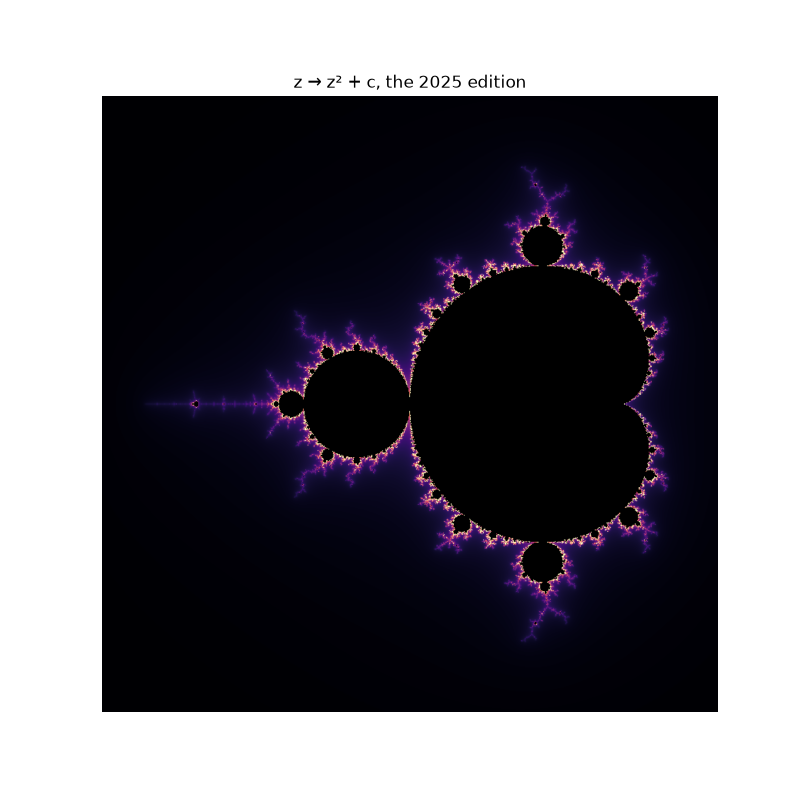

In [11]:
# Cell 3
# The full set in color

mu = escape_time(-0.75 + 0j, span=2.9, pixels=800, max_iter=250)
show(mu, -0.75 + 0j, 2.9, cmap="magma", title="z → z² + c, the 2025 edition")

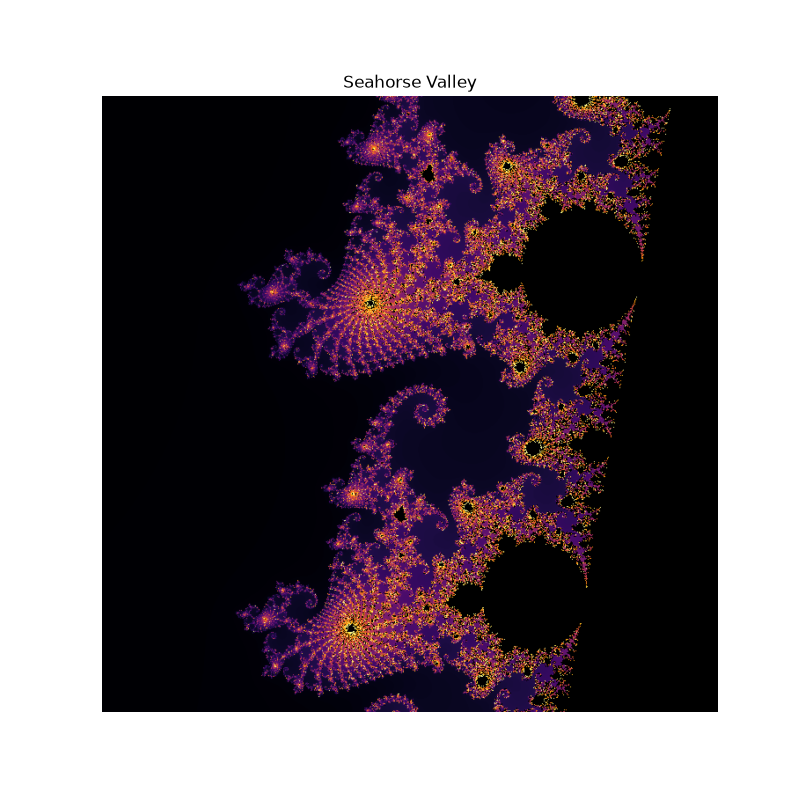

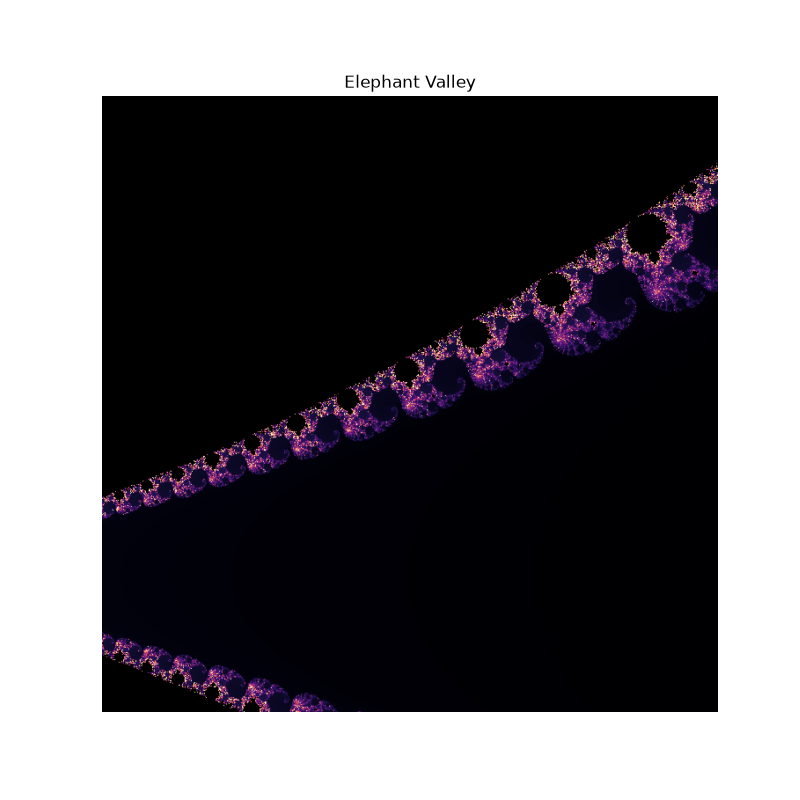

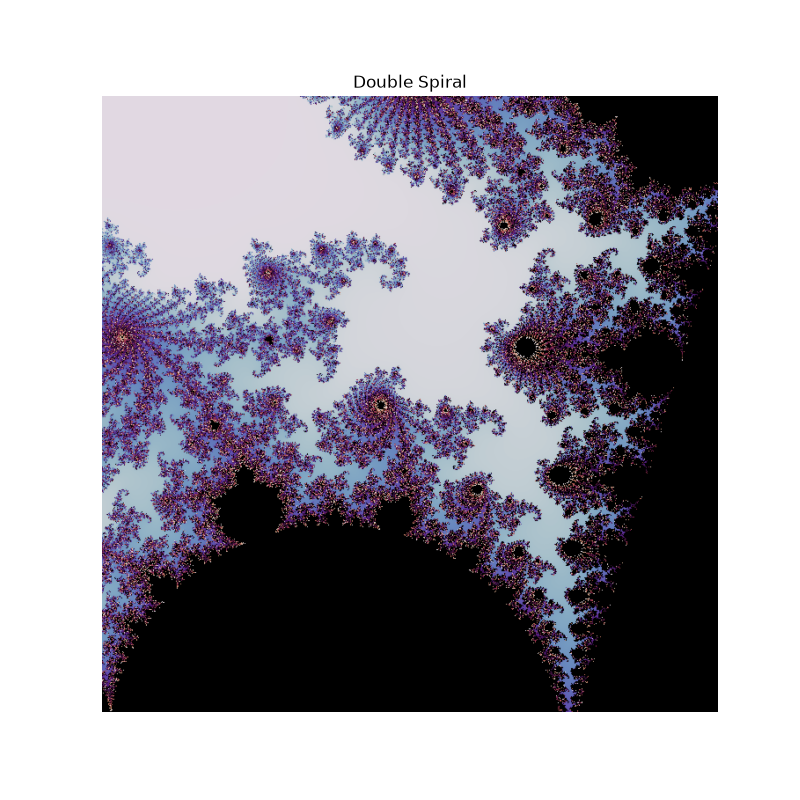

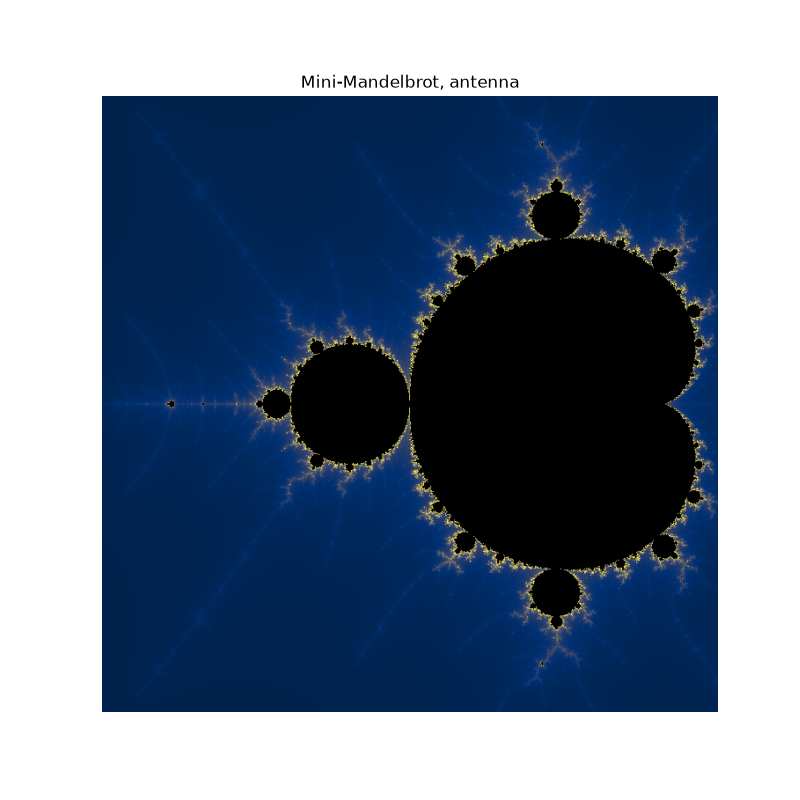

In [12]:
# Cell4 
# Scenic Overlooks
LANDMARKS = {
    "Seahorse Valley":          (-0.7455 + 0.1127j, 0.015, "inferno"),
    "Elephant Valley":          ( 0.2760 + 0.0070j, 0.025, "magma"),
    "Double Spiral":            (-0.7269 + 0.1889j, 0.010, "twilight"),
    "Mini-Mandelbrot, antenna": (-1.7685 + 0.0j,    0.045, "cividis"),
}
for name, (c0, sp, cm) in LANDMARKS.items():
    show(escape_time(c0, sp, pixels=700, max_iter=600), c0, sp, cmap=cm, title=name)

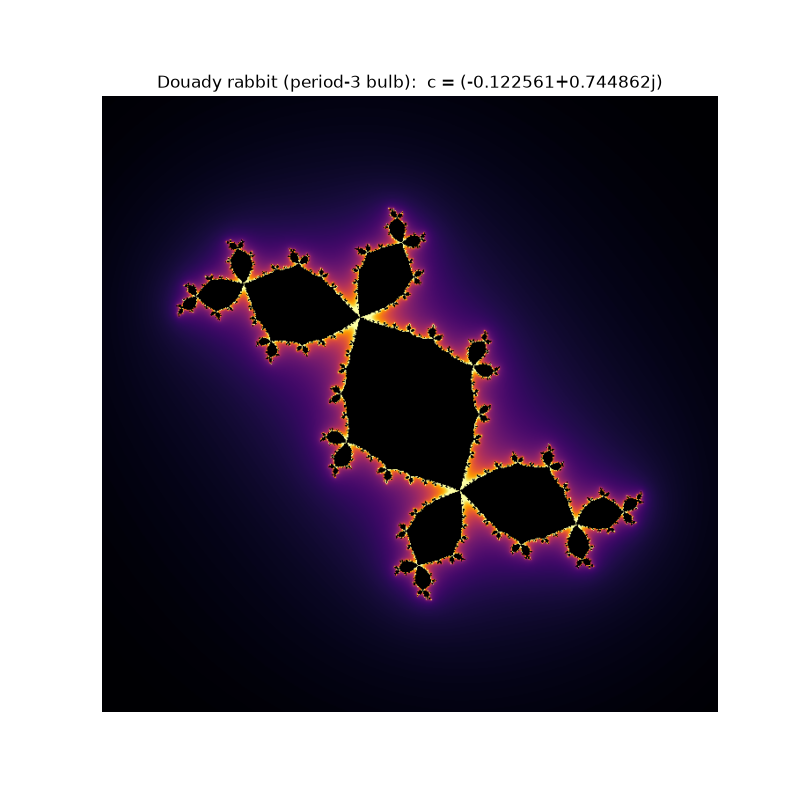

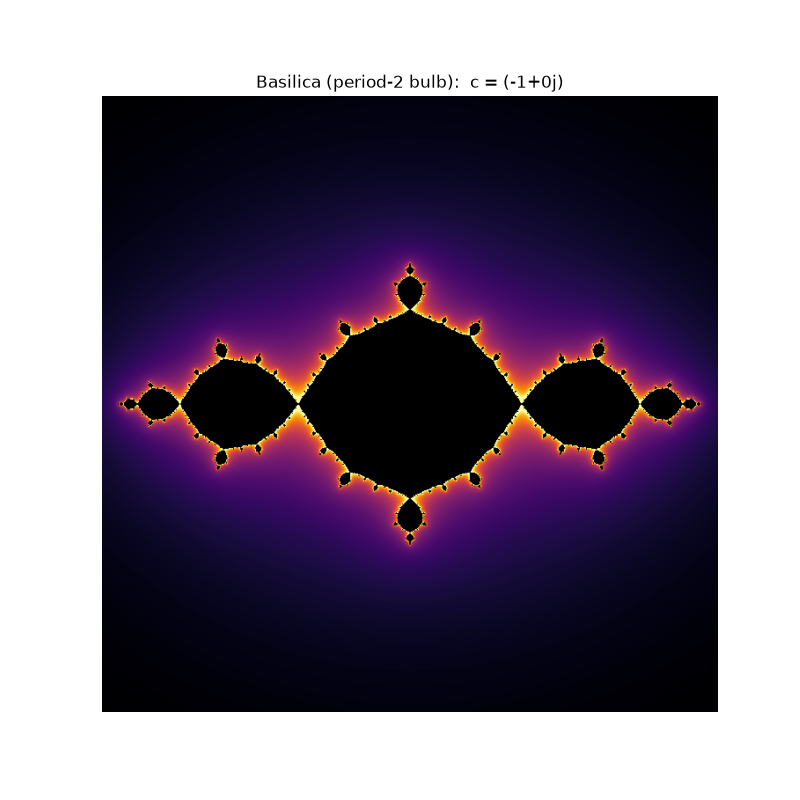

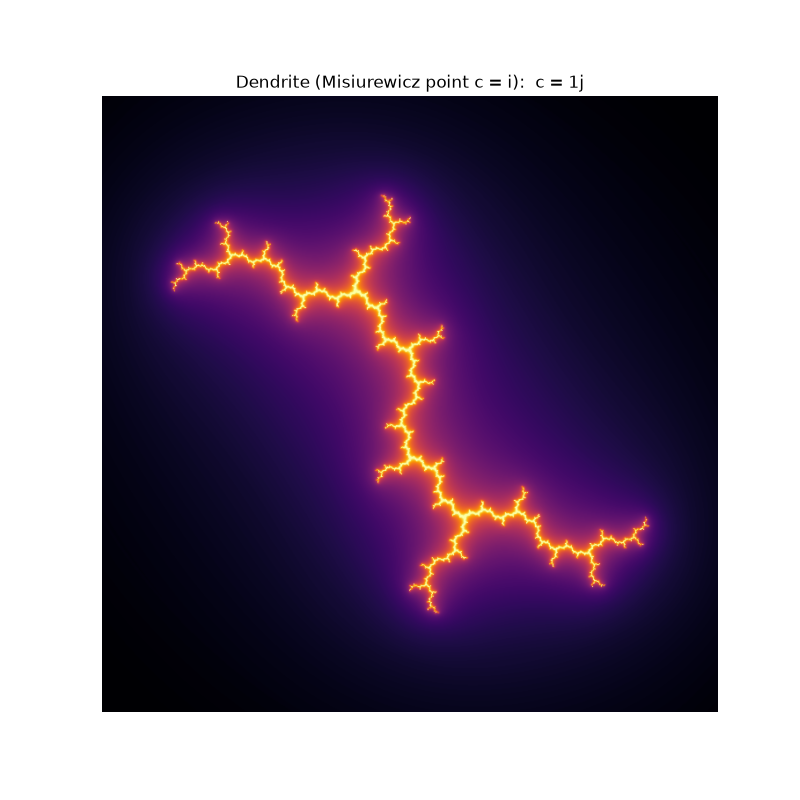

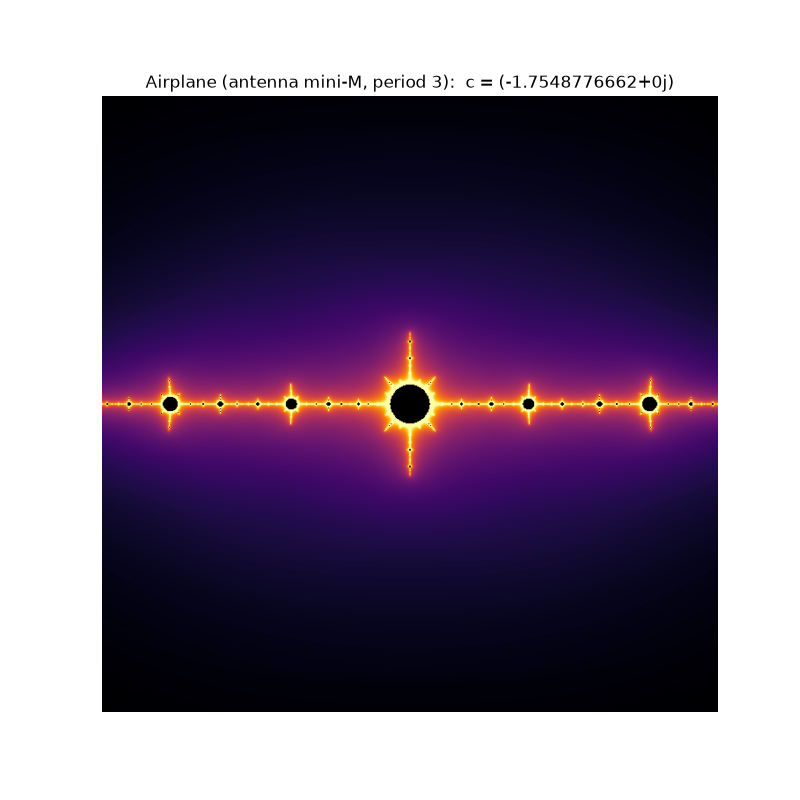

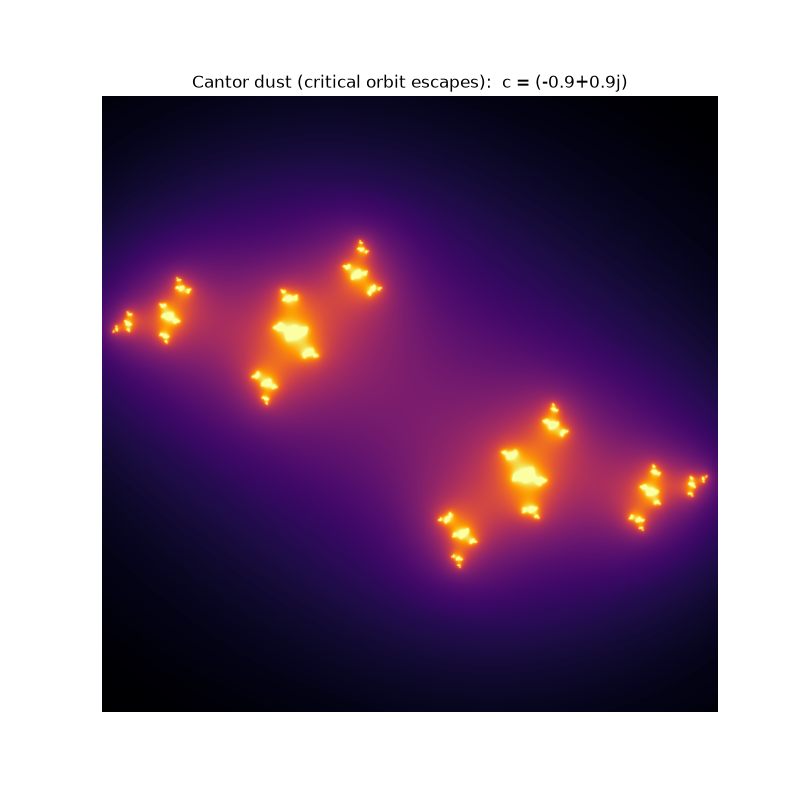

In [13]:
#  Cell 5 — the Douady dictionary (connected when c is in M,
#  Cantor dust when it isn't — the dichotomy now in pictures)

JULIAS = {
    "Douady rabbit (period-3 bulb)":        -0.122561 + 0.744862j,
    "Basilica (period-2 bulb)":             -1.0 + 0j,
    "Dendrite (Misiurewicz point c = i)":   1j,
    "Airplane (antenna mini-M, period 3)":  -1.7548776662 + 0j,
    "Cantor dust (critical orbit escapes)": -0.9 + 0.9j,
}
for name, c in JULIAS.items():
    show(escape_time(0j, 3.4, pixels=700, max_iter=400, julia_c=c),
         0j, 3.4, cmap="inferno", title=f"{name}:  c = {c}")

In [ ]:
# Cell 6--Interactive Explorer

import ipywidgets as widgets

def explore(re_center=-0.75, im_center=0.0, halvings=0, max_iter=400,
            cmap="magma", julia_c=""):
    span = 3.0 / 2**halvings          # 40 halvings ≈ 20 ulps per pixel in float64
    jc = None
    if julia_c.strip():
        try:
            jc = complex(julia_c)
        except ValueError:
            return print("Couldn't parse c — use a form like -0.75+0.1j")
    center = complex(re_center, im_center)
    show(escape_time(center, span, pixels=600, max_iter=max_iter, julia_c=jc),
         center, span, cmap=cmap)

widgets.interact_manual(
    explore,
    re_center=widgets.FloatText(-0.75, description="Re center"),
    im_center=widgets.FloatText(0.0, description="Im center"),
    halvings=widgets.IntSlider(0, 0, 40, description="zoom (halvings)"),
    max_iter=widgets.IntSlider(400, 100, 3000, 100, description="max iter"),
    cmap=["magma", "inferno", "twilight", "twilight_shifted", "viridis", "cividis"],
    julia_c=widgets.Text("", placeholder="Julia c, e.g. -0.123+0.745j (blank = Mandelbrot)"),
);


interactive(children=(FloatText(value=-0.75, description='Re center'), FloatText(value=0.0, description='Im ce…

CPU times: user 87 ms, sys: 2.15 ms, total: 89.2 ms
Wall time: 6.47 ms


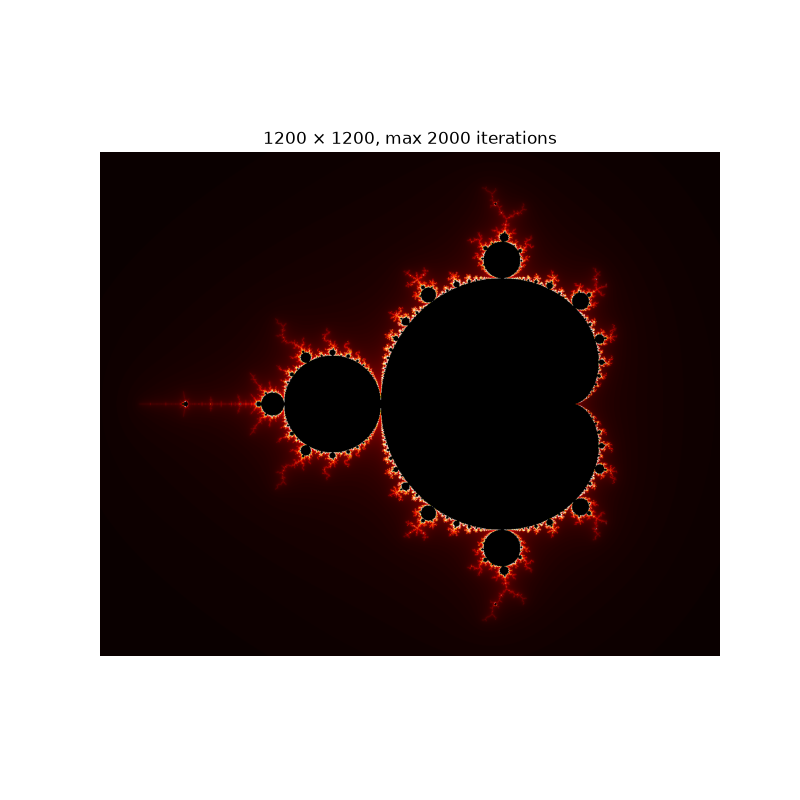

In [15]:
# Moore's law payoff

re = np.linspace(-2.2, 1.0, 1200)
im = np.linspace(-1.3, 1.3, 1200)
%time img = _engine(re, im, 2000, 0.0, 0.0, False)
cm = mpl.colormaps["hot"].copy()
cm.set_bad("black")
plt.figure(figsize=(8, 8))
shown = plt.imshow(np.ma.masked_invalid(img), cmap=cm, origin="lower",
                   extent=(re[0], re[-1], im[0], im[-1]))
lim = color_limits(np.ma.masked_invalid(img).compressed())
if lim:
    shown.set_clim(*lim)
plt.axis("off"); plt.title("1200 × 1200, max 2000 iterations"); plt.show()


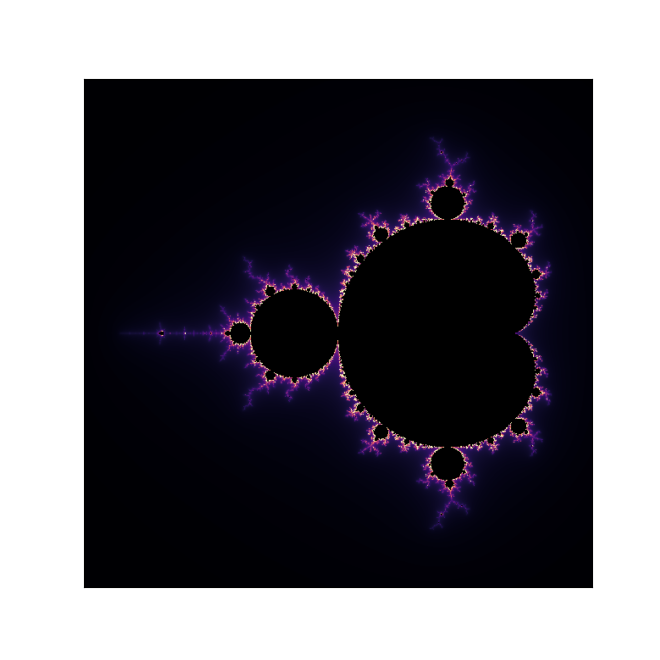

In [16]:
# Cell 9--Explorer  

%matplotlib widget

import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

LANDMARKS = {
    "Seahorse Valley":   (-0.7455 + 0.1127j, 0.015),
    "Elephant Valley":   ( 0.2760 + 0.0072j, 0.020),
    "Triple spiral":     (-0.0880 + 0.6540j, 0.030),
    "Double spiral":     (-0.7269 + 0.1889j, 0.010),
    "Mini-M on antenna": (-1.7685 + 0.0000j, 0.045),
    "Misiurewicz c = i": ( 0.0000 + 1.0000j, 0.040),
}

class FractalExplorer:
    """Click-to-zoom Mandelbrot/Julia explorer for ipympl notebooks.

    left-click      zoom in 2× toward the cursor
    right-click     zoom out 2×   (shift-click works too)
    scroll wheel    zoom at cursor
    middle-click    recenter without zooming
    ctrl-click      point-and-shoot: jump to the Julia set for that c
    """

    def __init__(self, pixels=600, cmap="magma"):
        self.pixels, self.cmap = pixels, cmap
        self.home = (-0.75 + 0j, 2.9)
        self.center, self.span = self.home
        self.zoom_ref = self.home[1]             # magnification is vs this span
        self.min_span = self.home[1] / 2**40     # float64: ~20 ulps per pixel
        self._axes_hold = False                  # True while a click owns the view
        self._limits = None                      # last limits this class applied
        self.base_iter, self.max_iter = 300, 300
        self.julia_c = None
        self.m_view = None                    # saved Mandelbrot view while in Julia mode
        self._syncing = False
        self._build_ui()
        self.render()

    # ---------------- UI ----------------
    def _build_ui(self):
        self.out = widgets.Output()
        with self.out:
            self.fig, self.ax = plt.subplots(figsize=(6.6, 6.6))
        self.ax.set_aspect("equal")
        self.ax.set_xticks([]); self.ax.set_yticks([])
        self.imshow = None

        self.status = widgets.HTML()
        self.landmarks = widgets.Dropdown(
            options=[("— jump to —", None)] + [(k, k) for k in LANDMARKS],
            value=None, layout=widgets.Layout(width="180px"))
        self.landmarks.observe(self._on_landmark, "value")
        self.cmap_dd = widgets.Dropdown(
            options=["magma", "inferno", "twilight_shifted", "viridis", "cividis", "hot"],
            value=self.cmap, layout=widgets.Layout(width="150px"))
        self.cmap_dd.observe(self._on_cmap, "value")

        self.btn_home = widgets.Button(description="⌂ home")
        self.btn_home.on_click(self._on_home)
        self.btn_back = widgets.Button(description="← Mandelbrot", disabled=True)
        self.btn_back.on_click(self._on_back)
        self.btn_save = widgets.Button(description="save PNG")
        self.btn_save.on_click(self._on_save)

        self.auto_iter = widgets.Checkbox(value=True, description="auto iterations", indent=False)
        self.auto_iter.observe(self._on_auto, "value")
        self.iter_slider = widgets.IntSlider(value=300, min=100, max=5000, step=50,
                                             description="max_iter", disabled=True,
                                             layout=widgets.Layout(width="380px"))
        self.iter_slider.observe(self._on_iter, "value")

        hint = widgets.HTML("<small><b>click</b> zoom in · <b>right/shift-click</b> out · "
                            "<b>scroll</b> zoom · <b>middle-click</b> recenter · "
                            "<b>ctrl-click</b> point-and-shoot Julia</small>")
        display(widgets.VBox([hint, self.out,
                              widgets.HBox([self.landmarks, self.cmap_dd, self.btn_home,
                                            self.btn_back, self.btn_save]),
                              widgets.HBox([self.auto_iter, self.iter_slider]),
                              self.status]))

        self.fig.canvas.mpl_connect("button_press_event", self._on_click)
        self.fig.canvas.mpl_connect("scroll_event", self._on_scroll)

    # ---------------- events ----------------
    def _toolbar_moved(self):
        if self._limits is None:
            return False
        (x0, x1), (y0, y1) = self.ax.get_xlim(), self.ax.get_ylim()
        lx0, lx1, ly0, ly1 = self._limits
        tol = 1e-8 * max(abs(lx1 - lx0), 1e-30)
        return (abs(x0 - lx0) > tol or abs(x1 - lx1) > tol
                or abs(y0 - ly0) > tol or abs(y1 - ly1) > tol)

    def _sync_from_axes(self):
        """Adopt a pan or zoom made with the toolbar buttons."""
        (x0, x1), (y0, y1) = self.ax.get_xlim(), self.ax.get_ylim()
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
        span = (x1 - x0 + y1 - y0) / 2
        if not np.isfinite(span) or span <= 0:
            return
        tol = 1e-12 * max(self.span, 1e-30)
        moved = abs(cx - self.center.real) > tol or abs(cy - self.center.imag) > tol
        resized = abs(span - self.span) > tol
        if moved or resized:
            self.center = complex(cx, cy)
            self.span = max(span, self.min_span)

    def _on_click(self, ev):
        if ev.inaxes is not self.ax or ev.xdata is None:
            return
        self._sync_from_axes()
        key = ev.key or ""
        if "ctrl" in key or "control" in key:
            if self.julia_c is None:                       # point-and-shoot
                self.m_view = (self.center, self.span)
                self._axes_hold = True
                self.julia_c = complex(ev.xdata, ev.ydata)
                self.center = 0j
                self.span = max(4.0, 2.5 * abs(self.julia_c))
                self.zoom_ref = self.span          # Julia zoom starts at 1×
                self.render()
            return
        if "shift" in key or ev.button == 3:
            self.zoom_at(ev.xdata, ev.ydata, 2.0)
        elif ev.button == 1:
            self.zoom_at(ev.xdata, ev.ydata, 0.5)
        elif ev.button == 2:
            self._axes_hold = True
            self.center = complex(ev.xdata, ev.ydata)
            self.render()

    def _on_scroll(self, ev):
        if ev.inaxes is not self.ax or ev.xdata is None:
            return
        self._sync_from_axes()
        self.zoom_at(ev.xdata, ev.ydata, 0.8 if ev.button == "up" else 1.25)

    def _on_landmark(self, change):
        if not change["new"]:
            return
        self._axes_hold = True
        self.center, self.span = LANDMARKS[change["new"]]
        self.julia_c = None
        self.zoom_ref = self.home[1]
        if self.auto_iter.value:
            self.max_iter = self._auto_iter()
        self.render()
        self.landmarks.value = None

    def _on_cmap(self, change):
        self.cmap = change["new"]
        if self.imshow is not None:
            self.imshow.set_cmap(self._cmap())
            self.fig.canvas.draw_idle()

    def _on_home(self, _):
        self._axes_hold = True
        self.center, self.span, self.julia_c = self.home[0], self.home[1], None
        self.zoom_ref = self.home[1]
        if self.auto_iter.value:
            self.max_iter = self.base_iter
        self.render()

    def _on_back(self, _):
        self._axes_hold = True
        self.julia_c = None
        if self.m_view:
            self.center, self.span = self.m_view
        self.zoom_ref = self.home[1]
        if self.auto_iter.value:
            self.max_iter = self._auto_iter()
        self.render()

    def _on_save(self, _):
        from datetime import datetime
        fname = datetime.now().strftime("fractal_%Y%m%d_%H%M%S.png")
        self.fig.savefig(fname, dpi=220, bbox_inches="tight")
        self.status.value = f"<small>saved <code>{fname}</code></small><br>" + self.status.value

    def _on_auto(self, change):
        self.iter_slider.disabled = change["new"]
        if change["new"]:
            self.max_iter = self._auto_iter()
            self.render()

    def _on_iter(self, change):
        if self._syncing:
            return
        self.max_iter = change["new"]
        self.render()

    # ---------------- math / rendering ----------------
    def _auto_iter(self):
        depth = np.log2(self.home[1] / self.span)          # zoom halvings since start
        return int(np.clip(self.base_iter + 60 * depth, self.base_iter, 5000))

    def zoom_at(self, x, y, factor):
        pt = complex(x, y)
        if factor < 1.0 and self.span * factor < self.min_span:
            if self.span <= self.min_span * (1.0 + 1e-9):
                return                                 # float64 zoom limit
            factor = self.min_span / self.span
        self._axes_hold = True
        self.center = pt + (self.center - pt) * factor     # keep the cursor point fixed
        self.span *= factor
        if self.auto_iter.value:
            self.max_iter = self._auto_iter()
        self.render()

    def _cmap(self):
        cm = mpl.colormaps[self.cmap].copy()
        cm.set_bad("black")
        return cm

    def render(self):
        if self.imshow is not None and not self._axes_hold and self._toolbar_moved():
            self._sync_from_axes()
        self._axes_hold = False
        t0 = time.time()
        re = np.linspace(self.center.real - self.span/2, self.center.real + self.span/2, self.pixels)
        im = np.linspace(self.center.imag - self.span/2, self.center.imag + self.span/2, self.pixels)
        jc = self.julia_c if self.julia_c is not None else 0j
        mu = _engine(re, im, self.max_iter, jc.real, jc.imag, self.julia_c is not None)
        data = np.ma.masked_invalid(mu)                    # interior (never escapes) -> black

        if self.imshow is None:
            self.imshow = self.ax.imshow(data, cmap=self._cmap(),
                                         origin="lower", interpolation="bilinear",
                                         extent=(re[0], re[-1], im[0], im[-1]))
        else:
            self.imshow.set_data(data)
            self.imshow.set_extent((re[0], re[-1], im[0], im[-1]))
        lim = color_limits(data.compressed())
        if lim:
            self.imshow.set_clim(*lim)
        self.ax.set_xlim(re[0], re[-1]); self.ax.set_ylim(im[0], im[-1])
        self._limits = (re[0], re[-1], im[0], im[-1])
        self.btn_back.disabled = self.julia_c is None

        self._syncing = True
        self.iter_slider.value = int(min(self.max_iter, 5000))
        self._syncing = False

        zoom = self.zoom_ref / self.span
        mode = (f"Julia, c = {self.julia_c.real:+.10g}{self.julia_c.imag:+.10g}i"
                if self.julia_c is not None else "Mandelbrot")
        warn = " &nbsp;⚠ float64 zoom limit" if self.span <= self.min_span * 1.01 else ""
        self.status.value = (f"<small><b>{mode}</b> · center "
                             f"{self.center.real:+.12g}{self.center.imag:+.12g}i · "
                             f"span {self.span:.3g} · zoom ×{zoom:,.0f} · "
                             f"max_iter {self.max_iter} · {time.time() - t0:.2f}s · "
                             f"engine: {_ACCEL}{warn}</small>")
        self.fig.canvas.draw_idle()

explorer = FractalExplorer()   # your 1985 machine, upgraded. Try FractalExplorer(pixels=400) if renders feel slow.


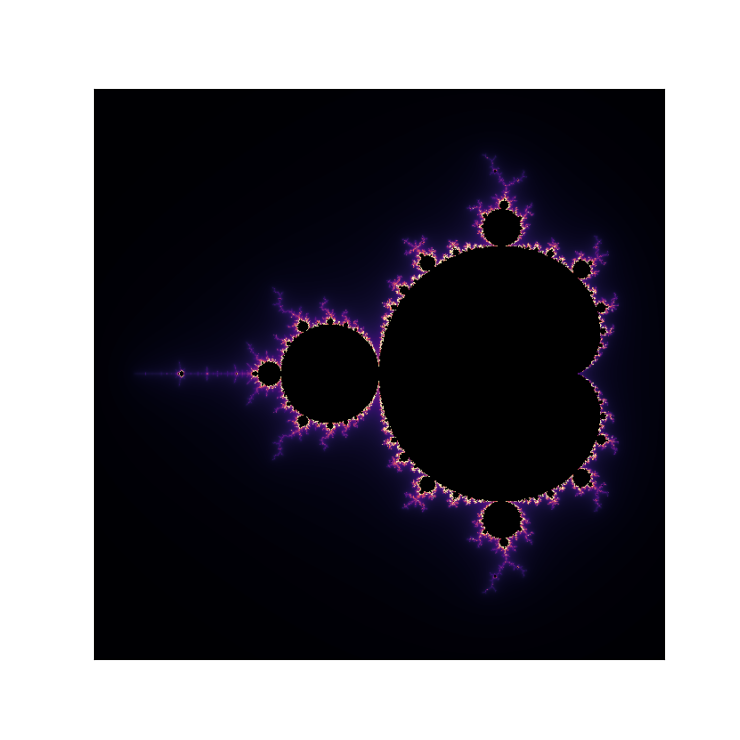

In [17]:
# Draw a box, magnify what's inside

%matplotlib widget

import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.widgets import RectangleSelector
import matplotlib.patheffects as pe
from IPython.display import display

class BoxMagnifier:
    """Drag a rectangle around a piece of the Mandelbrot set.

    The points inside the box are recomputed and become the new picture.
    Shift-drag forces a square. Right-click, or ←, steps back one box.
    """

    def __init__(self, pixels=640, cmap="magma"):
        self.long_pixels = pixels
        self.cmap_name = cmap
        # same window as the explorer's home view
        self.home = (-2.2, 0.7, -1.45, 1.45)          # x0, x1, y0, y1
        self.bounds = self.home
        self.history = []
        self.min_span = 2.9 / 2**40                    # float64: ~20 ulps per pixel
        self.base_iter = 300
        self.max_iter = self.base_iter
        self._build_ui()
        self.render()

    def _build_ui(self):
        self.out = widgets.Output()
        with self.out:
            self.fig, self.ax = plt.subplots(figsize=(7.2, 7.2))
        self.ax.set_aspect("equal", adjustable="box")
        self.ax.set_xticks([]); self.ax.set_yticks([])
        try:
            self.fig.canvas.toolbar_visible = False
        except Exception:
            pass
        self.imshow = None

        self.status = widgets.HTML()
        self.btn_back = widgets.Button(description="← back", disabled=True)
        self.btn_back.on_click(lambda _: self.back())
        self.btn_home = widgets.Button(description="⌂ home")
        self.btn_home.on_click(lambda _: self.home_view())
        hint = widgets.HTML(
            "<small><b>drag a box</b> to magnify the points inside · "
            "<b>shift-drag</b> square · <b>right-click</b> or ← back</small>")
        display(widgets.VBox([
            hint, self.out,
            widgets.HBox([self.btn_back, self.btn_home]),
            self.status]))

        # useblit stays off: a blitted rectangle is skipped by the widget
        # canvas, so the box never appears while you drag.
        self.selector = RectangleSelector(
            self.ax, self._on_select,
            useblit=False, button=[1],
            minspanx=8, minspany=8, spancoords="pixels",
            interactive=False,
            props=dict(facecolor=(1.0, 0.86, 0.1, 0.35),
                       edgecolor="#ffe14a", linewidth=2.8, fill=True,
                       zorder=5,
                       path_effects=[pe.Stroke(linewidth=6, foreground="black"),
                                     pe.Normal()]))
        self.fig.canvas.mpl_connect("button_press_event", self._on_click)
        self.fig.canvas.mpl_connect("key_press_event", self._on_key)

    def _on_click(self, ev):
        if ev.button == 3 and ev.inaxes is self.ax:
            self.back()

    def _on_key(self, ev):
        if ev.key == "left":
            self.back()

    def _on_select(self, eclick, erelease):
        if eclick.xdata is None or erelease.xdata is None:
            return
        if eclick.ydata is None or erelease.ydata is None:
            return
        x0, x1 = sorted((float(eclick.xdata), float(erelease.xdata)))
        y0, y1 = sorted((float(eclick.ydata), float(erelease.ydata)))
        # keep the box on the picture that is actually showing
        xa, xb, ya, yb = self.bounds
        x0, x1 = max(x0, xa), min(x1, xb)
        y0, y1 = max(y0, ya), min(y1, yb)
        if x1 <= x0 or y1 <= y0:
            return
        if x1 - x0 < self.min_span or y1 - y0 < self.min_span:
            self.status.value = ("<small>⚠ that box is past the float64 zoom limit"
                                 " — release a larger one</small>")
            return
        self.history.append(self.bounds)
        self.bounds = (x0, x1, y0, y1)
        self.max_iter = self._auto_iter()
        self.render()

    def _auto_iter(self):
        hx = self.home[1] - self.home[0]
        short = min(self.bounds[1] - self.bounds[0], self.bounds[3] - self.bounds[2])
        depth = np.log2(hx / short)
        return int(np.clip(self.base_iter + 60 * depth, self.base_iter, 5000))

    def back(self):
        if not self.history:
            return
        self.bounds = self.history.pop()
        self.max_iter = self._auto_iter()
        self.render()

    def home_view(self):
        self.history.clear()
        self.bounds = self.home
        self.max_iter = self.base_iter
        self.render()

    def _shape(self, w, h):
        long = self.long_pixels
        if w >= h:
            nx = long
            ny = max(48, int(round(long * h / w)))
        else:
            ny = long
            nx = max(48, int(round(long * w / h)))
        return nx, ny

    def _cmap(self):
        cm = mpl.colormaps[self.cmap_name].copy()
        cm.set_bad("black")
        return cm

    def render(self):
        t0 = time.time()
        x0, x1, y0, y1 = self.bounds
        w, h = x1 - x0, y1 - y0
        nx, ny = self._shape(w, h)
        re = np.linspace(x0, x1, nx)
        im = np.linspace(y0, y1, ny)
        mu = _engine(re, im, self.max_iter, 0.0, 0.0, False)
        data = np.ma.masked_invalid(mu)

        if self.imshow is None:
            self.imshow = self.ax.imshow(
                data, cmap=self._cmap(), origin="lower", interpolation="bilinear",
                extent=(re[0], re[-1], im[0], im[-1]))
        else:
            self.imshow.set_data(data)
            self.imshow.set_extent((re[0], re[-1], im[0], im[-1]))
        lim = color_limits(data.compressed())
        if lim:
            self.imshow.set_clim(*lim)
        self.ax.set_xlim(re[0], re[-1])
        self.ax.set_ylim(im[0], im[-1])

        long, short = 7.4, max(2.2, 7.4 * min(w, h) / max(w, h))
        if w >= h:
            self.fig.set_size_inches(long, short, forward=True)
        else:
            self.fig.set_size_inches(short, long, forward=True)

        self.btn_back.disabled = not self.history
        zoom = ((self.home[1] - self.home[0]) * (self.home[3] - self.home[2])) / (w * h)
        warn = " &nbsp;⚠ float64 zoom limit" if min(w, h) <= self.min_span * 1.01 else ""
        self.status.value = (
            f"<small><b>Mandelbrot</b> · "
            f"[{x0:+.12g}, {x1:+.12g}] × [{y0:+.12g}, {y1:+.12g}] · "
            f"{nx}×{ny} · zoom ×{zoom:,.1f} · "
            f"max_iter {self.max_iter} · {time.time() - t0:.2f}s · "
            f"engine: {_ACCEL}{warn}</small>")
        self.fig.canvas.draw_idle()

if "_engine" not in globals():
    print("Run the engine cell above first — this one uses its engine.")
else:
    boxzoom = BoxMagnifier()   # BoxMagnifier(pixels=400) if a drag feels slow


In [18]:
# new cell — the video writer, once (it wasn't in the earlier installs)
%pip install -q imageio imageio-ffmpeg

Note: you may need to restart the kernel to use updated packages.


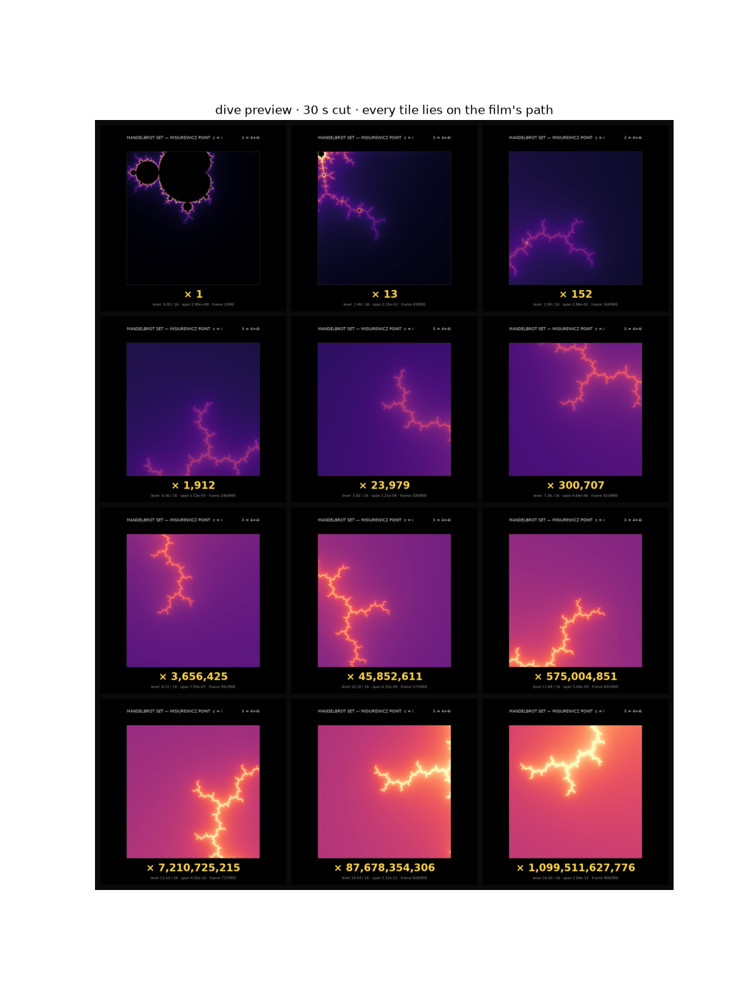

  frame   90/900 ·     1s elapsed · ~8s left
  frame  180/900 ·     2s elapsed · ~7s left
  frame  270/900 ·     2s elapsed · ~6s left
  frame  360/900 ·     3s elapsed · ~5s left
  frame  450/900 ·     4s elapsed · ~4s left
  frame  540/900 ·     5s elapsed · ~3s left
  frame  630/900 ·     5s elapsed · ~2s left
  frame  720/900 ·     6s elapsed · ~2s left
  frame  810/900 ·     7s elapsed · ~1s left
  frame  900/900 ·     8s elapsed · ~0s left
wrote misiurewicz_dive.mp4 — 900 frames at 30 fps in 8s


[embedded movie removed for GitHub - the .mp4 is kept locally]


In [19]:
# Cell 10 — The dive: a movie at a Misiurewicz point
#
# Center c* = i.  Critical orbit 0 → i → −1+i → −i → −1+i → ⋯
# (preperiod 2, period 2), cycle multiplier λ = 4+4i:
#     |λ| = 4√2 = 2^2.5 — the motif recurs every |λ| of zoom
#     arg λ = 45°       — each recurrence is turned 45°
# The float64 floor (40 halvings of span) is exactly 16 levels of |λ|.
# The film: 16 recurrences, 720° of turn, odometer ending at 2^40.

import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

_RESAMPLE = getattr(Image, "Resampling", Image)     # Pillow old & new

_fdir = Path(mpl.get_data_path()) / "fonts" / "ttf"  # DejaVu ships with matplotlib
def _font(name, size):
    try:
        return ImageFont.truetype(str(_fdir / name), size)
    except Exception:
        return ImageFont.load_default()
F_TITLE = _font("DejaVuSans.ttf", 18)
F_TAG   = _font("DejaVuSans.ttf", 18)
F_BIG   = _font("DejaVuSans-Bold.ttf", 46)
F_SUB   = _font("DejaVuSans.ttf", 16)

def dive(seconds=30, fps=30, pixels=600, margin=120, cmap="magma",
         fname="misiurewicz_dive.mp4", preview=False):
    """Render the dive to an H.264 mp4 (via imageio-ffmpeg).
       preview=True renders a 12-frame contact sheet instead — run it first.
       Uses _engine from Cell 1; numba strongly recommended
       (~0.1 s/frame with it, ~2-4 s/frame without)."""
    N = int(round(seconds * fps))
    center = 1j
    span0, halvings = 2.9, 40.0
    cm = mpl.colormaps[cmap]
    S = pixels + 2 * margin
    clim = None                          # temporally smoothed color limits

    def frame(k):
        nonlocal clim
        depth = halvings * k / (N - 1)               # constant speed in log2
        span = span0 * 2.0 ** (-depth)
        max_iter = int(np.clip(300 + 60 * depth, 300, 5000))
        re = np.linspace(center.real - span/2, center.real + span/2, pixels)
        im = np.linspace(center.imag - span/2, center.imag + span/2, pixels)
        mu = _engine(re, im, max_iter, 0.0, 0.0, False)

        finite = mu[np.isfinite(mu)]
        if finite.size:
            lo, hi = np.percentile(finite, [0.5, 99.5])
            clim = (lo, hi) if clim is None else (0.85*clim[0] + 0.15*lo,
                                                  0.85*clim[1] + 0.15*hi)
        lo, hi = clim if clim else (0.0, 1.0)
        if not hi > lo:
            hi = lo + 1.0
        v = np.clip((mu - lo) / (hi - lo), 0.0, 1.0)
        rgba = cm(v, bytes=True)
        rgba[~np.isfinite(mu)] = (0, 0, 0, 255)      # interior → black

        canvas = Image.new("RGB", (S, S), (0, 0, 0))
        canvas.paste(Image.fromarray(np.ascontiguousarray(rgba[..., :3])),
                     (margin, margin))
        d = ImageDraw.Draw(canvas)
        d.rectangle([margin - 1, margin - 1, margin + pixels, margin + pixels],
                    outline=(60, 60, 60), width=1)

        level = depth / 2.5                          # |λ| = 2^2.5 per level
        d.text((margin, int(margin * 0.38)),
               "MANDELBROT SET — MISIUREWICZ POINT  c = i",
               font=F_TITLE, fill=(210, 210, 210))
        tag = "λ = 4+4i"
        d.text((margin + pixels - d.textlength(tag, font=F_TAG), int(margin * 0.38)),
               tag, font=F_TAG, fill=(210, 210, 210))
        big = f"× {round(2.0 ** depth):,d}"
        d.text(((S - d.textlength(big, font=F_BIG)) / 2, margin + pixels + 16),
               big, font=F_BIG, fill=(255, 210, 74))
        sub = f"level {level:5.2f} / 16 · span {span:.2e} · frame {k + 1}/{N}"
        d.text(((S - d.textlength(sub, font=F_SUB)) / 2, margin + pixels + 80),
               sub, font=F_SUB, fill=(150, 150, 150))
        return canvas

    if preview:
        picks = np.linspace(0, N - 1, 12).round().astype(int)
        tiles = [frame(k).resize((420, 420), _RESAMPLE.LANCZOS) for k in picks]
        sheet = Image.new("RGB", (3*420 + 4*12, 4*420 + 5*12), (10, 10, 10))
        for t, tile in enumerate(tiles):
            sheet.paste(tile, (12 + (t % 3) * 432, 12 + (t // 3) * 432))
        plt.figure(figsize=(10.5, 14))
        plt.imshow(sheet); plt.axis("off")
        plt.title(f"dive preview · {seconds:.0f} s cut · every tile lies on the film's path")
        plt.show()
        return

    writer = None
    try:
        import imageio.v2 as imageio
        writer = imageio.get_writer(fname, fps=fps, codec="libx264", quality=8,
                                    pixelformat="yuv420p", macro_block_size=1)
    except Exception as e:
        outdir = Path("dive_frames"); outdir.mkdir(exist_ok=True)
        print(f"no video writer ({type(e).__name__}) — writing PNGs to {outdir}/")

    t0 = time.time()
    for k in range(N):
        img = frame(k)
        if writer is not None:
            writer.append_data(np.asarray(img))
        else:
            img.save(Path("dive_frames") / f"frame_{k:04d}.png")
        if (k + 1) % max(1, N // 10) == 0 or k == N - 1:
            el = time.time() - t0
            print(f"  frame {k+1:4d}/{N} · {el:5.0f}s elapsed · "
                  f"~{el/(k+1)*(N-k-1):.0f}s left")
    if writer is not None:
        writer.close()
        print(f"wrote {fname} — {N} frames at {fps} fps in {time.time()-t0:.0f}s")
        from IPython.display import Video, display
        display(Video(fname, embed=True, width=560))
    else:
        print("assemble with:  ffmpeg -framerate 30 -i dive_frames/frame_%04d.png "
              "-c:v libx264 -pix_fmt yuv420p -crf 18 dive.mp4")

if "_engine" not in globals():
    print("Run Cell 1 first — the dive uses its engine.")
else:
    dive(preview=True)    # check framing, pacing, and the odometer first
    dive()              # then: the 30 s film.  dive(seconds=60) = the stately cut

In [ ]:
# Cell 11 — Measure arg λ from pixels
# Two renders one |λ| level apart: the deeper frame should be the shallower
# one turned by arg λ = 45°.  Correlation over trial rotations finds it.

import numpy as np
from PIL import Image
_R = getattr(Image, "Resampling", Image)

def _field(span, pixels=384, max_iter=600):
    re = np.linspace(-span/2, span/2, pixels)          # window centered at c* = i
    im = np.linspace(1 - span/2, 1 + span/2, pixels)
    mu = _engine(re, im, max_iter, 0.0, 0.0, False)
    v = np.zeros(mu.shape)
    ok = np.isfinite(mu) & (mu > 0)
    v[ok] = np.log2(mu[ok])                            # the banding signal
    return v

s = 1e-7                                               # ~10 levels deep: asymptotic
A = _field(s)
B = _field(s / np.hypot(4.0, 4.0))                     # one λ-level deeper
Bimg = Image.fromarray(np.uint8(np.clip((B - B.min()) / (np.ptp(B) + 1e-9), 0, 1) * 255))
inset = 384 // 6                                       # ignore rotated corners

def match(deg):
    R = np.asarray(Bimg.rotate(deg, resample=_R.BILINEAR))[inset:-inset, inset:-inset]
    return np.corrcoef(A[inset:-inset, inset:-inset].ravel(), R.ravel())[0, 1]

coarse = max(range(-90, 91, 3), key=match)
fine = max(range(coarse - 4, coarse + 5), key=match)
print(f"correlation at  0°: {match(0):.3f}")
print(f"best angle    {fine:+3d}°: {match(fine):.3f}")
print(f"λ = 4+4i predicts ±45° — the dive turns {(-fine):+d}° per level, "
      f"{(-16*fine):+.0f}° over sixteen levels.")

In [20]:
# Cell 12--The tripling dive
#
# A movie at the period-TRIPLING Feigenbaum point, where the whole
# Mandelbrot set keeps coming back.
#
# The real "airplane" minibrot (period 3, nucleus -1.754877666...) carries
# its own airplane (period 9), which carries its own (period 27), and so on:
#     period    3:  c = -1.75487766624669
#     period    9:  c = -1.78586564641067    ratio 56.63
#     period   27:  c = -1.78642985805576    ratio 54.92
#     period   81:  c = -1.78644006735908    ratio 55.264
#     period  243:  c = -1.78644025215704    ratio 55.2458
#     period  729:  c = -1.78644025550198    ratio 55.24711
#     period 2187:  c = -1.78644025556252    ratio 55.24702
# The nuclei converge to c* = -1.78644025556364 at rate delta_3 = 55.247
# (the tripling cousin of Feigenbaum's 4.6692).  Zooming about c* by delta_3
# maps each minibrot onto the next one -- a FULL copy of M every level.
#
# Unlike Cell 10 (Misiurewicz: spirals that turn 45 deg per level, minibrots
# shrinking off to the side), here the copy is centered and upright, because
# delta_3 is real and positive: no rotation.
#
# Framing: the view is c* + (w - c*) * s for the opening frame's w, scale s.
# That is a pure zoom about c*, and it frames every minibrot exactly the way
# the opening frame shows the real Mandelbrot set.
#
# Coloring: escape counts near the period-3^n minibrot are ~3^n times the
# counts near M itself, so the frame colors log(mu / 3^level) against ONE
# fixed range (measured once at level 1).  Every copy gets the same colors,
# and the loop is seamless -- no flicker from per-frame color limits.
#
# Float64 budget: 2^40 of zoom = log(2^40)/log(55.247) = 6.9 levels, down to
# the period-729 minibrot.
# Cost: escape counts triple every level, so max_iter must too (300 * 3^level,
# ~590k at the bottom).  Cycle detection in _engine only catches periods <= 20,
# so minibrot interiors of period 27+ run to max_iter.  Measured on a 32-core
# M3 Ultra at 600 px: ~0.01 s/frame at level 1, ~3.8 s at level 6, ~7 s at 6.9
# -> a 30 s / 900-frame film takes roughly 20 minutes.

import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

C_STAR  = -1.78644025556364          # period-tripling accumulation point
DELTA_3 = 55.247                     # tripling scaling constant
LOG2_D3 = np.log2(DELTA_3)           # = 5.788 halvings per level

_RS = getattr(Image, "Resampling", Image)            # Pillow old & new
_fd = Path(mpl.get_data_path()) / "fonts" / "ttf"    # DejaVu ships with matplotlib
def _tfont(name, size):
    try:
        return ImageFont.truetype(str(_fd / name), size)
    except Exception:
        return ImageFont.load_default()
T_TITLE = _tfont("DejaVuSans.ttf", 18)
T_BIG   = _tfont("DejaVuSans-Bold.ttf", 46)
T_SUB   = _tfont("DejaVuSans.ttf", 16)

def tripling_dive(seconds=30, fps=30, pixels=600, margin=120, cmap="magma",
                  halvings=40.0, iter_base=300, iter_cap=600_000,
                  fname="tripling_dive.mp4", preview=False):
    """Render the tripling dive to an H.264 mp4 (via imageio-ffmpeg).
       preview=True renders a 12-frame contact sheet instead -- run it first.
       Uses _engine from Cell 1."""
    N = int(round(seconds * fps))
    w0, span0 = -0.75 + 0j, 2.9          # opening frame: the whole set
    levels = halvings / LOG2_D3          # 6.9 for 40 halvings
    cm = mpl.colormaps[cmap]
    S = pixels + 2 * margin

    def render(level, px):
        s = DELTA_3 ** (-level)
        span = span0 * s
        center = C_STAR + (w0 - C_STAR) * s          # pure zoom about c*
        max_iter = int(min(iter_base * 3.0 ** level, iter_cap))
        re = np.linspace(center.real - span/2, center.real + span/2, px)
        im = np.linspace(center.imag - span/2, center.imag + span/2, px)
        return _engine(re, im, max_iter, 0.0, 0.0, False), max_iter

    # one fixed color range, measured on the first minibrot (level 1),
    # on log(mu / 3^level) so the outer glow is not crushed to black
    def shade(mu, level):
        x = np.full(mu.shape, np.nan)
        ok = np.isfinite(mu) & (mu > 0)
        x[ok] = np.log(mu[ok] / 3.0 ** level)
        return x
    x1 = shade(render(1.0, max(pixels // 2, 200))[0], 1.0)
    lo, hi = np.nanpercentile(x1, [0.5, 99.5])
    if not hi > lo:
        hi = lo + 1.0

    def frame(k):
        depth = halvings * k / max(N - 1, 1)         # constant speed in log2
        level = depth / LOG2_D3
        span = span0 * 2.0 ** (-depth)
        mu, max_iter = render(level, pixels)
        v = np.clip((np.nan_to_num(shade(mu, level), nan=lo) - lo) / (hi - lo), 0.0, 1.0)
        rgba = cm(v, bytes=True)
        rgba[~np.isfinite(mu)] = (0, 0, 0, 255)      # interior -> black
        rgb = np.ascontiguousarray(rgba[::-1, :, :3])  # row 0 = top (imag up)

        canvas = Image.new("RGB", (S, S), (0, 0, 0))
        canvas.paste(Image.fromarray(rgb), (margin, margin))
        d = ImageDraw.Draw(canvas)
        d.rectangle([margin - 1, margin - 1, margin + pixels, margin + pixels],
                    outline=(60, 60, 60), width=1)

        d.text((margin, int(margin * 0.38)),
               "MANDELBROT SET — TRIPLING POINT",
               font=T_TITLE, fill=(210, 210, 210))
        tag = f"c* = {C_STAR:.14g}"
        d.text((margin + pixels - d.textlength(tag, font=T_TITLE), int(margin * 0.38)),
               tag, font=T_TITLE, fill=(210, 210, 210))
        big = f"× {round(2.0 ** depth):,d}"
        d.text(((S - d.textlength(big, font=T_BIG)) / 2, margin + pixels + 16),
               big, font=T_BIG, fill=(255, 210, 74))
        n = int(round(level))
        who = "the Mandelbrot set" if n == 0 else f"minibrot of period 3^{n} = {3**n:,d}"
        sub = (f"level {level:4.2f} / {levels:.1f} · {who} · "
               f"δ₃ ≈ 55.247 · span {span:.2e} · frame {k + 1}/{N}")
        d.text(((S - d.textlength(sub, font=T_SUB)) / 2, margin + pixels + 80),
               sub, font=T_SUB, fill=(150, 150, 150))
        return canvas

    if preview:
        picks = np.linspace(0, N - 1, 12).round().astype(int)
        tiles = [frame(k).resize((420, 420), _RS.LANCZOS) for k in picks]
        sheet = Image.new("RGB", (3*420 + 4*12, 4*420 + 5*12), (10, 10, 10))
        for t, tile in enumerate(tiles):
            sheet.paste(tile, (12 + (t % 3) * 432, 12 + (t // 3) * 432))
        plt.figure(figsize=(10.5, 14))
        plt.imshow(sheet); plt.axis("off")
        plt.title(f"tripling dive preview · {seconds:.0f} s cut · {levels:.1f} copies of M")
        plt.show()
        return

    writer = None
    try:
        import imageio.v2 as imageio
        writer = imageio.get_writer(fname, fps=fps, codec="libx264", quality=8,
                                    pixelformat="yuv420p", macro_block_size=1)
    except Exception as e:
        outdir = Path("tripling_frames"); outdir.mkdir(exist_ok=True)
        print(f"no video writer ({type(e).__name__}) — writing PNGs to {outdir}/")

    print(f"rendering {N} frames — later frames are slower (max_iter triples per level)")
    t0 = time.time()
    for k in range(N):
        img = frame(k)
        if writer is not None:
            writer.append_data(np.asarray(img))
        else:
            img.save(Path("tripling_frames") / f"frame_{k:04d}.png")
        if (k + 1) % max(1, N // 10) == 0 or k == N - 1:
            print(f"  frame {k+1:4d}/{N} · {time.time() - t0:6.0f}s elapsed")
    if writer is not None:
        writer.close()
        print(f"wrote {fname} — {N} frames at {fps} fps in {time.time()-t0:.0f}s")
        from IPython.display import Video, display
        display(Video(fname, embed=True, width=560))
    else:
        print("assemble with:  ffmpeg -framerate 30 -i tripling_frames/frame_%04d.png "
              "-c:v libx264 -pix_fmt yuv420p -crf 18 tripling_dive.mp4")

if "_engine" not in globals():
    print("Run Cell 1 first — the dive uses its engine.")
else:
    tripling_dive(preview=True)   # check framing and pacing first (~30 s)
    tripling_dive()               # then the 30 s film (~20 min on the M3 Ultra)

KeyboardInterrupt: 

In [5]:
# Cell 13--Brent kernel
#
# Same signature and same smooth escape counts as _engine in Cell 1, but
# interior detection uses Brent's cycle finding, which catches a cycle of ANY
# period.  Cell 1 refreshes its reference point every 20 steps, so it only
# catches periods <= 20; inside the period-27 ... 729 minibrots of the tripling
# dive every interior pixel ran all ~590,000 iterations before giving up.
#
# Brent: keep a saved point; after 1, 2, 4, 8, ... steps move it to the
# current z.  Once the orbit has settled onto a p-cycle, the saved point is ON
# the cycle and the orbit returns to it within p steps of some window >= p.
# As in Cell 1, a near-return is only believed after one more full lap returns
# again AND the cycle multiplier |(f^p)'|^2 < 1 (attracting -> interior).
# Measured against Cell 1 on tripling frames: identical pictures (0 pixels
# differ), 3-7x faster at levels 5-6.9.
#
# use_brent(True)  -> every cell that calls _engine (explorer, box magnifier,
#                     dives) now uses this kernel
# use_brent(False) -> back to Cell 1's kernel exactly

import time
import numpy as np
from numba import njit, prange

@njit(parallel=True, fastmath=True)
def _engine_brent(re, im, max_iter, cre, cim, julia):
    out = np.empty((im.size, re.size))
    if julia:
        cabs = np.hypot(cre, cim)
        R = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * cabs))
        bail = 16.0 if R < 4.0 else R * R
    else:
        bail = 16.0
    # A "return" must land far closer than one pixel: (pixel/100)^2, clamped
    # between Cell 1's 1e-20 and float64's rounding floor.  A fixed 1e-20
    # wrongly blacked out ~1% of OUTSIDE pixels at tripling level 6, where the
    # whole frame is only 1e-10 wide.
    dx = abs(re[1] - re[0]) if re.size > 1 else 1.0
    tol = min(1e-20, max(1e-30, (0.01 * dx) ** 2))
    for j in prange(im.size):
        yi = im[j]
        y2 = yi * yi
        for i in range(re.size):
            xi = re[i]
            if julia:
                zr, zi, cr, ci = xi, yi, cre, cim
            else:
                zr, zi, cr, ci = 0.0, 0.0, xi, yi
                xq = xi - 0.25
                q = xq * xq + y2
                if q * (q + xq) <= 0.25 * y2 or (xi + 1.0) * (xi + 1.0) + y2 <= 0.0625:
                    out[j, i] = np.inf
                    continue
            z2 = zr * zr + zi * zi
            if z2 > bail:
                out[j, i] = 1.0 - np.log2(np.log2(z2) * 0.5)
                continue
            mu = np.inf
            sr, si = zr, zi          # Brent's saved point
            power, lam = 1, 0        # window length, steps since saved
            vr = vi = 0.0            # candidate periodic point while verifying
            left = 0                 # verification countdown
            wm2 = 1.0                # |(f^p)'|^2 over the verification lap
            for k in range(1, max_iter + 1):
                zr, zi = zr*zr - zi*zi + cr, 2.0*zr*zi + ci
                z2 = zr*zr + zi*zi
                if not z2 <= bail:                       # escaped (NaN-safe)
                    if np.isfinite(z2) and z2 > 1.0:
                        mu = k - np.log2(np.log2(z2) * 0.5) + 1.0
                    else:
                        mu = float(k)
                    break
                if left > 0:                             # verification lap
                    wm2 *= 4.0 * z2
                    left -= 1
                    if left == 0:
                        dr, di = zr - vr, zi - vi
                        if dr*dr + di*di < tol and wm2 < 1.0:
                            break                        # attracting -> interior
                        sr, si, power, lam = zr, zi, 1, 0  # false alarm; restart
                    continue
                lam += 1
                dr, di = zr - sr, zi - si
                if dr*dr + di*di < tol:                  # returned after lam steps
                    vr, vi, left, wm2 = zr, zi, lam, 1.0
                elif lam == power:                       # window full: move saved
                    sr, si = zr, zi
                    power *= 2
                    lam = 0
            out[j, i] = mu
    return out

if "_engine_classic" not in globals():
    _engine_classic = _engine            # Cell 1's kernel, kept for use_brent(False)

def use_brent(on=True):
    global _engine
    _engine = _engine_brent if on else _engine_classic
    print("engine:", "Brent (any period)" if on else "Cell 1 classic (periods <= 20)")

def _bench(level=6.0, pixels=300):
    """Deep tripling frame (Cell 12's framing): both kernels, same pixels."""
    c_star, d3 = -1.78644025556364, 55.247
    s = d3 ** (-level); span = 2.9 * s
    center = c_star + (-0.75 - c_star) * s
    max_iter = int(min(300 * 3.0 ** level, 600_000))
    re = np.linspace(center - span/2, center + span/2, pixels)
    im = np.linspace(-span/2, span/2, pixels)
    _engine_brent(re[:4], im[:4], 10, 0.0, 0.0, False)   # compile outside the timer
    t0 = time.time(); a = _engine_classic(re, im, max_iter, 0.0, 0.0, False); ta = time.time() - t0
    t0 = time.time(); b = _engine_brent(re, im, max_iter, 0.0, 0.0, False);  tb = time.time() - t0
    same_inside = np.mean(np.isfinite(a) == np.isfinite(b))
    both = np.isfinite(a) & np.isfinite(b)
    worst = np.max(np.abs(a[both] - b[both])) if both.any() else 0.0
    print(f"tripling level {level} ({pixels} px, max_iter {max_iter:,d}):")
    print(f"  Cell 1 kernel {ta:6.2f} s   Brent kernel {tb:6.2f} s   -> {ta / tb:4.1f}x faster")
    print(f"  inside/outside agreement {100 * same_inside:.3f}%   "
          f"largest escape-count difference {worst:.2e}")

if "_engine" not in globals():
    print("Run Cell 1 first.")
else:
    _bench()
    use_brent(True)      # now re-run Cell 12 (or tripling_dive()) to feel the difference

tripling level 6.0 (300 px, max_iter 218,700):
  Cell 1 kernel   0.90 s   Brent kernel   0.29 s   ->  3.1x faster
  inside/outside agreement 100.000%   largest escape-count difference 0.00e+00
engine: Brent (any period)


In [6]:
# Cell 14--Edge dive tools: snap a click to a self-repeating point
#
# Every exactly self-repeating spot on the fringe is a MISIUREWICZ point:
# the critical orbit 0 -> c -> c^2+c -> ... lands, after k steps (preperiod),
# on a repelling cycle of period p.  Near such a point the set repeats every
# |lam| of zoom, turned by arg(lam), where lam = (f^p)' around the cycle =
# product of 2z over the p cycle points.  (Cell 10's c = i: k=2, p=2, lam=4+4i.)
# Misiurewicz points are dense in the boundary -- wherever you click on the
# fringe, one is close by.
#
# How to pick: in the Explorer (Cell 9), zoom in by LEFT-CLICKING on the spot
# you like.  This cell listens to the Explorer and remembers the last point you
# clicked (ctrl-clicks and Julia mode are ignored).  Then run Cell 15.
#
# snap_misiurewicz(c0, radius) solves f^(k+p)(0) = f^k(0) by Newton's method
# from your click for k = 2..K, p = 1..P, keeps genuine Misiurewicz points
# (exact preperiod and period checked, |lam| > 1), and ranks them by distance.

import numpy as np

def _orbit(c, n):
    z, zs = 0j, [0j]
    for _ in range(n):
        z = z * z + c
        zs.append(z)
    return zs

def _newton_mis(c, k, p, steps=80):
    """Newton on g(c) = z_{k+p}(c) - z_k(c), with dz/dc carried along."""
    for _ in range(steps):
        z, dz = 0j, 0j
        zk = dzk = 0j
        for n in range(1, k + p + 1):
            dz = 2.0 * z * dz + 1.0
            z = z * z + c
            if n == k:
                zk, dzk = z, dz
            if abs(z) > 1e6:
                return None
        g, dg = z - zk, dz - dzk
        if dg == 0:
            return None
        step = g / dg
        c -= step
        if abs(step) < 1e-16 * max(1.0, abs(c)):
            return c
    return c if abs(step) < 1e-12 else None

def classify(c, K=40, P=16):
    """Exact (preperiod k, period p, lam) of c's critical orbit, or None.
       Nuclei (orbit returns to 0, k = 0) and non-landing orbits -> None."""
    zs = _orbit(c, K + 2 * P + 2)
    scale = 1e-9
    for p in range(1, P + 1):
        for k in range(0, K + 1):
            if abs(zs[k + p] - zs[k]) < scale * (1.0 + abs(zs[k])):
                # confirm the next lap too (rules out a chance near-miss)
                if abs(zs[k + 2 * p] - zs[k + p]) > scale * (1.0 + abs(zs[k])):
                    break
                if k == 0:
                    return None                       # periodic: a nucleus
                lam = 1.0 + 0j
                for j in range(k, k + p):
                    lam *= 2.0 * zs[j]
                if abs(lam) <= 1.0 + 1e-9:
                    return None
                return k, p, lam
    return None

def snap_misiurewicz(c0, radius=None, K=24, P=8, top=5):
    """Misiurewicz points near c0, nearest first.  radius: keep only points
       within this distance (default: anything Newton finds)."""
    found = []
    for p in range(1, P + 1):
        for k in range(2, K + 1):
            c = _newton_mis(complex(c0), k, p)
            if c is None or not np.isfinite(c.real) or not np.isfinite(c.imag):
                continue
            info = classify(c)
            if info is None:
                continue
            if radius is not None and abs(c - c0) > radius:
                continue
            if any(abs(c - f[0]) < 1e-11 * max(1.0, abs(c)) for f in found):
                continue
            found.append((c, *info))
    found.sort(key=lambda f: abs(f[0] - c0))
    return found[:top]

def describe(m, c0=None):
    c, k, p, lam = m
    levels = 40.0 / np.log2(abs(lam))
    s = (f"c* = {c.real:+.15f} {c.imag:+.15f}i   preperiod {k}, period {p}   "
         f"|λ| = {abs(lam):.4g}, arg λ = {np.degrees(np.angle(lam)):+.2f}°   "
         f"→ {levels:.1f} repeats in float64")
    if c0 is not None:
        s += f"   ({abs(c - c0):.2e} from your click)"
    return s

# ---- listen to the Explorer for the spot you like ----
_edge_pick = globals().get("_edge_pick")

def _remember_click(ev):
    global _edge_pick
    ex = globals().get("explorer")
    if ex is None or ev.inaxes is not ex.ax or ev.xdata is None:
        return
    key = ev.key or ""
    if "ctrl" in key or "control" in key or ex.julia_c is not None:
        return
    if ev.button in (1, 2):
        _edge_pick = complex(ev.xdata, ev.ydata)

if "explorer" in globals():
    if getattr(explorer, "_edge_cid", None) is not None:
        explorer.fig.canvas.mpl_disconnect(explorer._edge_cid)   # re-run safe
    explorer._edge_cid = explorer.fig.canvas.mpl_connect("button_press_event", _remember_click)
    print("Listening: left-click a spot on the fringe in the Explorer (Cell 9), "
          "zoom in as far as you like, then run Cell 15.")
else:
    print("Explorer not running — Cell 15 will use a Seahorse Valley spot, "
          "or call snap_misiurewicz(your_c) yourself.")

Listening: left-click a spot on the fringe in the Explorer (Cell 9), zoom in as far as you like, then run Cell 15.


→ c* = -0.386865773878119 +0.623950778705118i   preperiod 17, period 1   |λ| = 1.034, arg λ = +136.36°   → 825.0 repeats in float64   (9.05e-03 from your click)
  c* = -0.378344229637952 +0.632964655585894i   preperiod 22, period 3   |λ| = 2.719, arg λ = -63.67°   → 27.7 repeats in float64   (1.30e-02 from your click)
  c* = -0.383636249340474 +0.632210095857962i   preperiod 12, period 5   |λ| = 3.535, arg λ = +86.12°   → 22.0 repeats in float64   (1.32e-02 from your click)
  c* = -0.390425544706744 +0.627701675026335i   preperiod 17, period 3   |λ| = 2.835, arg λ = -63.69°   → 26.6 repeats in float64   (1.40e-02 from your click)
  c* = -0.386828510533939 +0.633017927865264i   preperiod 22, period 2   |λ| = 3.525, arg λ = +45.91°   → 22.0 repeats in float64   (1.54e-02 from your click)


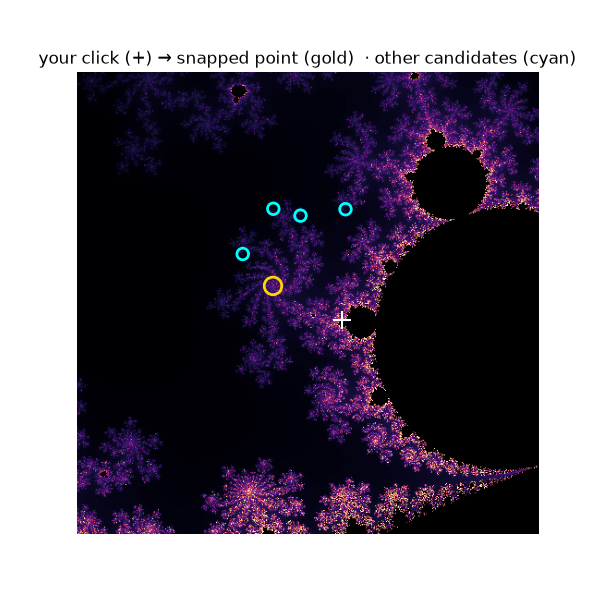

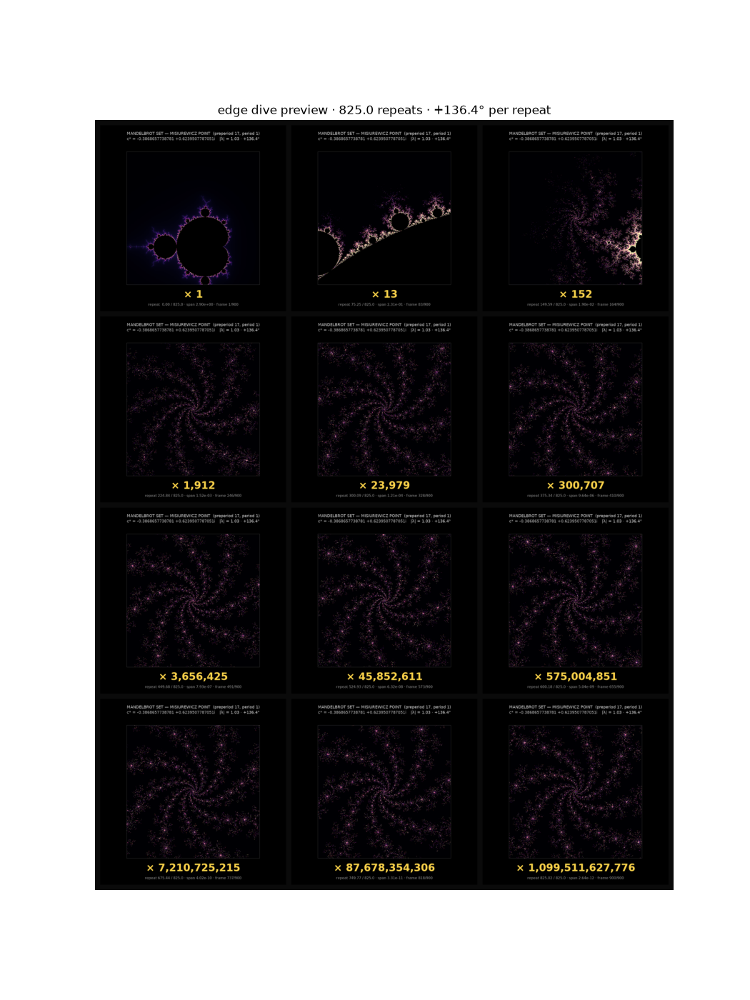

  frame   90/900 ·      1s elapsed
  frame  180/900 ·      2s elapsed
  frame  270/900 ·      4s elapsed
  frame  360/900 ·      5s elapsed
  frame  450/900 ·      7s elapsed
  frame  540/900 ·     10s elapsed
  frame  630/900 ·     12s elapsed
  frame  720/900 ·     15s elapsed
  frame  810/900 ·     19s elapsed
  frame  900/900 ·     22s elapsed
wrote edge_dive_k17_p1.mp4 — 900 frames at 30 fps in 23s


[embedded movie removed for GitHub - the .mp4 is kept locally]


In [7]:
# Cell 15--The edge dive: a movie at the self-repeating point nearest your click
#
# Uses the last spot you left-clicked in the Explorer (Cell 14 is listening),
# snaps it to the nearest Misiurewicz point, and dives there.
#   zoom rate: the motif returns every |lam| of zoom
#   twist:     each return is turned by arg(lam)
#   colors:    each return adds exactly p iterations to the escape count
#              (one more lap around the period-p cycle), so the frame colors
#              mu - p*level against ONE fixed range -> every repeat matches
# corotate=True turns the camera with the spiral, so the repeating motif
# holds still while the zoom pours through it.

import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

_RSe = getattr(Image, "Resampling", Image)
_fde = Path(mpl.get_data_path()) / "fonts" / "ttf"
def _efont(name, size):
    try:
        return ImageFont.truetype(str(_fde / name), size)
    except Exception:
        return ImageFont.load_default()
E_TITLE = _efont("DejaVuSans.ttf", 18)
E_BIG   = _efont("DejaVuSans-Bold.ttf", 46)
E_SUB   = _efont("DejaVuSans.ttf", 16)

def edge_dive(m, seconds=30, fps=30, pixels=600, margin=120, cmap="magma",
              halvings=40.0, corotate=False, fname=None, preview=False):
    """m = (c*, k, p, lam) from snap_misiurewicz.  preview=True -> contact sheet."""
    c_star, k_pre, p, lam = m
    N = int(round(seconds * fps))
    span0 = 2.9
    log2lam = np.log2(abs(lam))
    turn = np.degrees(np.angle(lam))                 # degrees per repeat
    levels = halvings / log2lam
    fname = fname or f"edge_dive_k{k_pre}_p{p}.mp4"
    cm = mpl.colormaps[cmap]
    S = pixels + 2 * margin
    pad = int(np.ceil(pixels * np.sqrt(2.0))) if corotate else pixels

    def render(depth, px):
        span = span0 * 2.0 ** (-depth) * px / pixels
        max_iter = int(min(300 + 60 * depth + p * depth / log2lam * 4, 50_000))
        re = np.linspace(c_star.real - span/2, c_star.real + span/2, px)
        im = np.linspace(c_star.imag - span/2, c_star.imag + span/2, px)
        return _engine(re, im, max_iter, 0.0, 0.0, False)

    # fixed color range on (mu - p*level), measured one repeat in
    d1 = min(log2lam, halvings)
    x1 = render(d1, max(pixels // 2, 200)) - p * (d1 / log2lam)
    lo, hi = np.percentile(x1[np.isfinite(x1)], [0.5, 99.5])
    if not hi > lo:
        hi = lo + 1.0

    def frame(kf):
        depth = halvings * kf / max(N - 1, 1)
        level = depth / log2lam
        mu = render(depth, pad)
        v = np.clip((mu - p * level - lo) / (hi - lo), 0.0, 1.0)
        rgba = cm(v, bytes=True)
        rgba[~np.isfinite(mu)] = (0, 0, 0, 255)
        img = Image.fromarray(np.ascontiguousarray(rgba[::-1, :, :3]))
        if corotate:                                  # undo the spiral's turn
            img = img.rotate(turn * level, resample=_RSe.BICUBIC)
            o = (pad - pixels) // 2
            img = img.crop((o, o, o + pixels, o + pixels))

        canvas = Image.new("RGB", (S, S), (0, 0, 0))
        canvas.paste(img, (margin, margin))
        d = ImageDraw.Draw(canvas)
        d.rectangle([margin - 1, margin - 1, margin + pixels, margin + pixels],
                    outline=(60, 60, 60), width=1)
        d.text((margin, int(margin * 0.22)),
               f"MANDELBROT SET — MISIUREWICZ POINT  (preperiod {k_pre}, period {p})",
               font=E_TITLE, fill=(210, 210, 210))
        d.text((margin, int(margin * 0.22) + 24),
               f"c* = {c_star.real:+.13f} {c_star.imag:+.13f}i",
               font=E_TITLE, fill=(170, 170, 170))
        tag = f"|λ| = {abs(lam):.3g} · {turn:+.1f}°"
        d.text((margin + pixels - d.textlength(tag, font=E_TITLE), int(margin * 0.22) + 24),
               tag, font=E_TITLE, fill=(210, 210, 210))
        big = f"× {round(2.0 ** depth):,d}"
        d.text(((S - d.textlength(big, font=E_BIG)) / 2, margin + pixels + 16),
               big, font=E_BIG, fill=(255, 210, 74))
        sub = (f"repeat {level:5.2f} / {levels:.1f} · "
               f"{'camera turning with the spiral · ' if corotate else ''}"
               f"span {span0 * 2.0 ** (-depth):.2e} · frame {kf + 1}/{N}")
        d.text(((S - d.textlength(sub, font=E_SUB)) / 2, margin + pixels + 80),
               sub, font=E_SUB, fill=(150, 150, 150))
        return canvas

    if preview:
        picks = np.linspace(0, N - 1, 12).round().astype(int)
        tiles = [frame(kf).resize((420, 420), _RSe.LANCZOS) for kf in picks]
        sheet = Image.new("RGB", (3*420 + 4*12, 4*420 + 5*12), (10, 10, 10))
        for t, tile in enumerate(tiles):
            sheet.paste(tile, (12 + (t % 3) * 432, 12 + (t // 3) * 432))
        plt.figure(figsize=(10.5, 14))
        plt.imshow(sheet); plt.axis("off")
        plt.title(f"edge dive preview · {levels:.1f} repeats · {turn:+.1f}° per repeat")
        plt.show()
        return

    import imageio.v2 as imageio
    writer = imageio.get_writer(fname, fps=fps, codec="libx264", quality=8,
                                pixelformat="yuv420p", macro_block_size=1)
    t0 = time.time()
    for kf in range(N):
        writer.append_data(np.asarray(frame(kf)))
        if (kf + 1) % max(1, N // 10) == 0 or kf == N - 1:
            print(f"  frame {kf+1:4d}/{N} · {time.time() - t0:6.0f}s elapsed")
    writer.close()
    print(f"wrote {fname} — {N} frames at {fps} fps in {time.time()-t0:.0f}s")
    from IPython.display import Video, display
    display(Video(fname, embed=True, width=560))

def show_snap(c0, cands, radius):
    """Your click (white +) and the candidates (rings; the chosen one gold)."""
    c_star = cands[0][0]
    span = max(radius, 6 * abs(c_star - c0), 1e-11)
    mid = (c0 + c_star) / 2
    px = 500
    re = np.linspace(mid.real - span/2, mid.real + span/2, px)
    im = np.linspace(mid.imag - span/2, mid.imag + span/2, px)
    mu = _engine(re, im, int(300 + 60 * max(0, np.log2(2.9 / span))), 0.0, 0.0, False)
    data = np.ma.masked_invalid(mu)
    cmm = mpl.colormaps["magma"].copy(); cmm.set_bad("black")
    plt.figure(figsize=(6, 6))
    h = plt.imshow(data, cmap=cmm, origin="lower", extent=(re[0], re[-1], im[0], im[-1]))
    lim = color_limits(data.compressed())
    if lim:
        h.set_clim(*lim)
    for j, (c, *_r) in enumerate(cands):
        plt.scatter([c.real], [c.imag], s=160 if j == 0 else 70, facecolors="none",
                    edgecolors="gold" if j == 0 else "cyan", linewidths=2)
    plt.scatter([c0.real], [c0.imag], marker="+", s=160, c="white")
    plt.xlim(re[0], re[-1]); plt.ylim(im[0], im[-1]); plt.axis("off")
    plt.title("your click (+) → snapped point (gold)  · other candidates (cyan)")
    plt.show()

if "snap_misiurewicz" not in globals():
    print("Run Cell 14 first.")
else:
    ex = globals().get("explorer")
    c0 = globals().get("_edge_pick")
    if c0 is None:
        c0 = -0.7436438870 + 0.1318259042j          # Seahorse Valley, if no click yet
        print("No click recorded yet — using a Seahorse Valley spot.")
    radius = ex.span if ex is not None else 0.05
    cands = snap_misiurewicz(c0, radius=radius) or snap_misiurewicz(c0)
    if not cands:
        print("No Misiurewicz point found near that click — try clicking right on the fringe.")
    else:
        for j, m in enumerate(cands):
            print(("→ " if j == 0 else "  ") + describe(m, c0))
        show_snap(c0, cands, radius)
        M_EDGE = cands[0]               # or cands[1], cands[2] ... to pick another
        edge_dive(M_EDGE, preview=True) # check framing first
        edge_dive(M_EDGE)               # the film; edge_dive(M_EDGE, corotate=True) holds the spiral still